## Creata a straight line dataset using the linear regression formaula (weight * X + bias)
set weight = 0.3 and bias = 0.9 there should be 100 datapoints total

Split the data inti 80% training and 20% test
Plot the training and testing data so that it becomest visual



In [ ]:
# Import necessary libraries
import torch
import matplotlib.pyplot as plt
from torch import nn


In [21]:
# Creating the data parameters
weight = 0.3
bias = 0.9

# Make X and y using linear regression feature
X = torch.arange(0, 1, 0.01).unsqueeze(dim= 1)
y = weight * X + bias

print(f"Number of samples: {len(X)}")
print(f"Number of samples: {len(y)}")
print(f"First 10  X  & y smaples:\nX:{X[:10]}\ny: {y[:10]}")


Number of samples: 100
Number of samples: 100
First 10  X  & y smaples:
X:tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])
y: tensor([[0.9000],
        [0.9030],
        [0.9060],
        [0.9090],
        [0.9120],
        [0.9150],
        [0.9180],
        [0.9210],
        [0.9240],
        [0.9270]])


In [22]:
# Split the data into training and testing
train_split = int(len(X) * 0.8)
X_train = X[:train_split]
y_train = y[:train_split]
X_test = X[train_split:]
y_test = y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(80, 80, 20, 20)

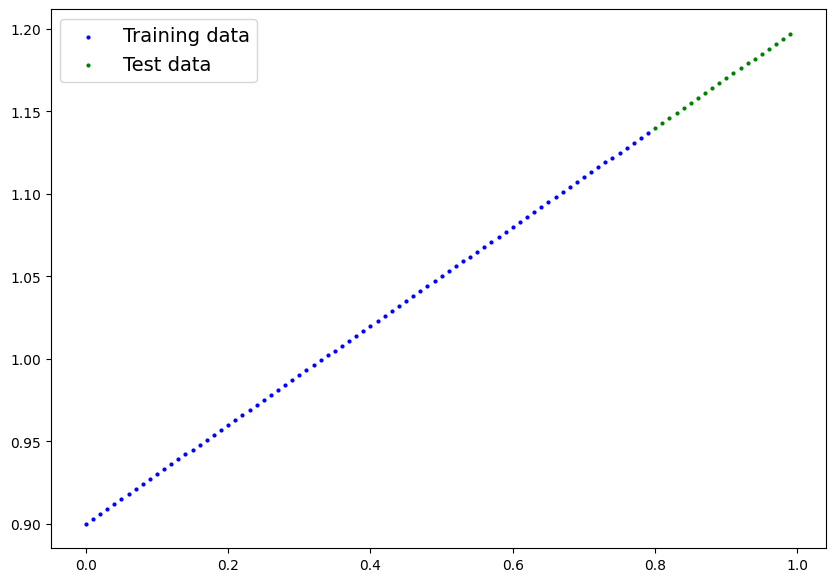

In [23]:
# Plot the training and testing data
def plot_predictions(train_data = X_train,
                 train_labels = y_train,
                 test_data = X_test,
                 test_labels = y_test,
                 predictions = None):
  plt.figure(figsize = (10,7))
  plt.scatter(train_data,train_labels,c = 'b',s = 4,label = "Training data")
  plt.scatter(test_data,test_labels,c = 'g',s = 4,label = "Test data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c = 'r',s = 4,label = "Predictions")
  plt.legend(prop = {"size" : 14})
plot_predictions()

## Build Pytorch model by subclassing nn.module ##



In [53]:
# Create pyTorch linear regression model by subclassing nn.Module
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(data=torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))

    self.bias = nn.Parameter(data=torch.randn(1,
                                               requires_grad=True,
                                               dtype=torch.float
                                               ))

  def forward(self, x):
    return self.weight * x + self.bias

# Option 2
# class LinearRegressionModel(nn.Module):
#   def __init__(self):
#     super().__init__()
#     self.linear_layer = nn.Linear(in_features = 1,
#                                   out_features = 1)

#   def forward(self, x: torch.Tensor) -> torch.Tensor:
#     return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearRegressionModel()
model_1, model_1.state_dict()


(LinearRegressionModel(),
 OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))]))

In [47]:
next(model_1.parameters()).device

device(type='cpu')

In [54]:
# Make sure device is defined first
device = "cuda" if torch.cuda.is_available() else "cpu"

# Move model to device
model_1 = LinearRegressionModel()  # (make sure it's defined)
model_1.to(device)

# List parameters
print(list(model_1.parameters()))


[Parameter containing:
tensor([0.2345], requires_grad=True), Parameter containing:
tensor([0.2303], requires_grad=True)]


In [55]:
# Instantiate the model and put it to the target device

model_1.to(device)
list(model_1.parameters())


[Parameter containing:
 tensor([0.2345], requires_grad=True),
 Parameter containing:
 tensor([0.2303], requires_grad=True)]

## Create loss function and optimizer using nn.L12Loss() and torch.optim.SGD(params, lr) respectively


In [51]:
# Create the loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr= 0.01)

In [56]:
# Training loop
# Train the model for 300 epochs

torch.manual_seed(42)

epochs = 300

# Send the data to target device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  # Training

  # Put the model in train mode
  model_1.train()

  # 1 Forward pass
  y_pred = model_1(X_train)

  # 2 . Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3 Zero the gradients
  optimizer.zero_grad()

  # 4 Backprop
  loss.backward()

  # 5 Step the optimizer
  optimizer.step()

  ### Perform the testing every 20 epochs
  if epoch % 20 == 0:
    # Put the model in evaluation mode and setup inference context
    model_1.eval()
    with torch.inference_mode():
      #1 Forward pass
      y_preds = model_1(X_test)
      # 2 Calculate test loss
      test_loss = loss_fn(y_preds, y_test)

      # Print out what is happening
      print(f" Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss: .3f}")





 Epoch: 0 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 20 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 40 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 60 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 80 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 100 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 120 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 140 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 160 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 180 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 200 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 220 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 240 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 260 | Train loss: 0.696 | Test loss:  0.728
 Epoch: 280 | Train loss: 0.696 | Test loss:  0.728


# Make predictions with the trained model on the test data #

In [58]:
# Make predictions with the model
model_1.eval()

with torch.inference_mode():
  y_preds = model_1(X_test)

y_preds

tensor([[0.4179],
        [0.4202],
        [0.4226],
        [0.4249],
        [0.4273],
        [0.4296],
        [0.4320],
        [0.4343],
        [0.4367],
        [0.4390],
        [0.4413],
        [0.4437],
        [0.4460],
        [0.4484],
        [0.4507],
        [0.4531],
        [0.4554],
        [0.4578],
        [0.4601],
        [0.4625]])

In [59]:
y_preds.cpu()

tensor([[0.4179],
        [0.4202],
        [0.4226],
        [0.4249],
        [0.4273],
        [0.4296],
        [0.4320],
        [0.4343],
        [0.4367],
        [0.4390],
        [0.4413],
        [0.4437],
        [0.4460],
        [0.4484],
        [0.4507],
        [0.4531],
        [0.4554],
        [0.4578],
        [0.4601],
        [0.4625]])

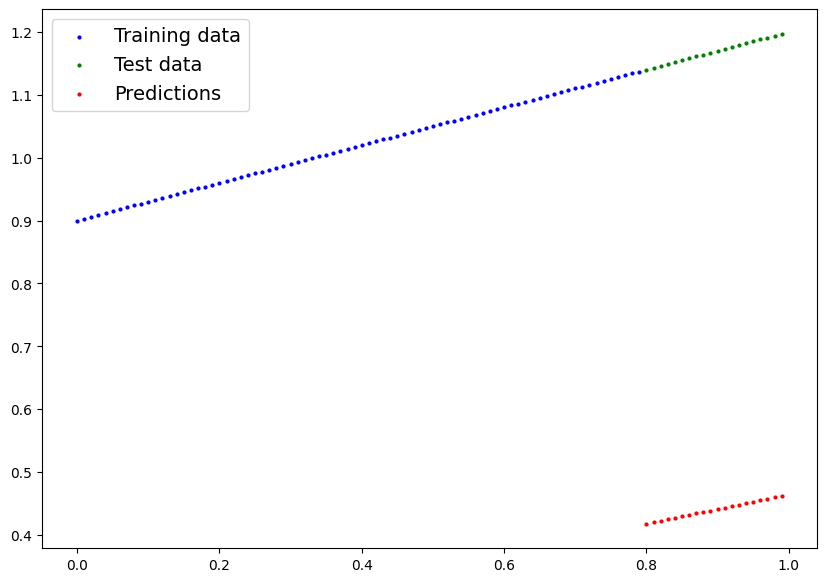

In [61]:
# Plot predictions (these may need to be on a specific device )
plot_predictions(predictions = y_preds.cpu())

# Saving the trained model's state_dict() to file


In [64]:
from pathlib import Path


# Creating model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# 2 Create model save path
MODEL_NAME = "01_pytorch_model"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to {MODEL_SAVE_PATH}")

torch.save(obj = model_1.state_dict() , f = MODEL_SAVE_PATH)

Saving model to models/01_pytorch_model


In [69]:
# Create a new instance of model and load saved state dict ( make sure to  it on the target device)
loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(f = MODEL_SAVE_PATH))
loaded_model.to(device)

LinearRegressionModel()

In [70]:
# Make predictions with loaded model and compare them to the previous
y_preds_new = loaded_model(X_test)
y_preds == y_preds_new


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [71]:
loaded_model.state_dict()

OrderedDict([('weight', tensor([0.2345])), ('bias', tensor([0.2303]))])